<a href="https://colab.research.google.com/github/Raju-kushwaha1230/ML/blob/main/standardization_scalling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('Social_Network_Ads.csv', usecols=['Age','EstimatedSalary','Purchased'] )


In [4]:
df.shape

(400, 3)

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
146,27,96000,1
323,48,30000,1
395,46,41000,1
51,18,44000,0
327,42,75000,0


In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scalar = StandardScaler()

In [8]:
from sklearn.model_selection import  train_test_split

In [9]:
X_train, X_test, y_train,y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=42 )

In [10]:
scalar.fit(X_train)

StandardScaler()

In [11]:
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [13]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [14]:
X_train_scaled.head()

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318


In [15]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.575000,70589.285714
std,10.196005,33948.504534
min,18.000000,15000.000000
25%,30.000000,44000.000000
50%,37.000000,71000.000000
75%,45.000000,88000.000000
max,60.000000,150000.000000


In [17]:
X_test.head()

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000


In [31]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


In [29]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


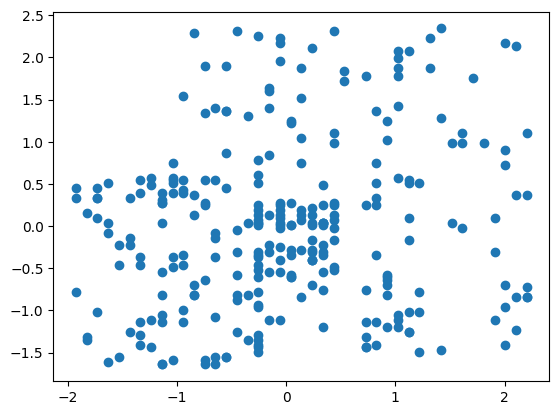

In [18]:
plt.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'])
#

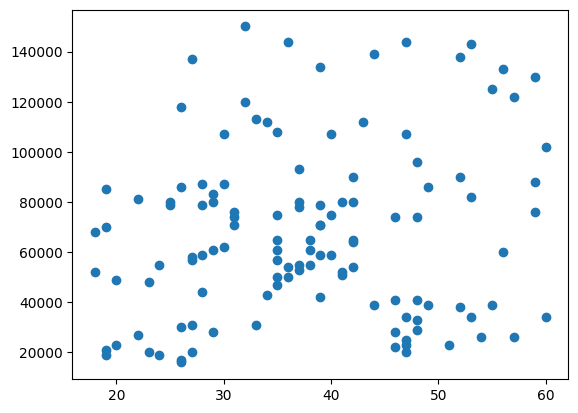

In [19]:
plt.scatter(X_test['Age'], X_test['EstimatedSalary'])


<Axes: xlabel='Age', ylabel='Density'>

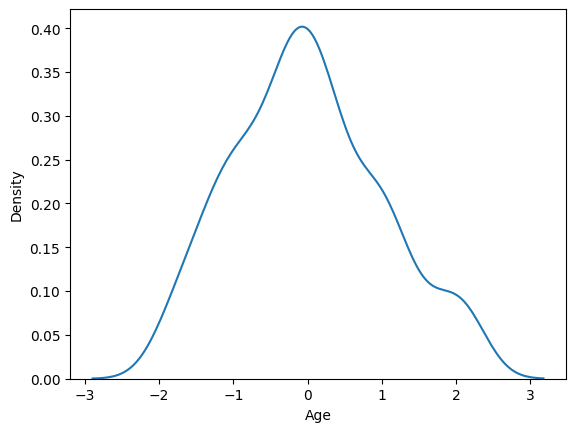

In [24]:
sns.kdeplot(X_train_scaled['Age'])


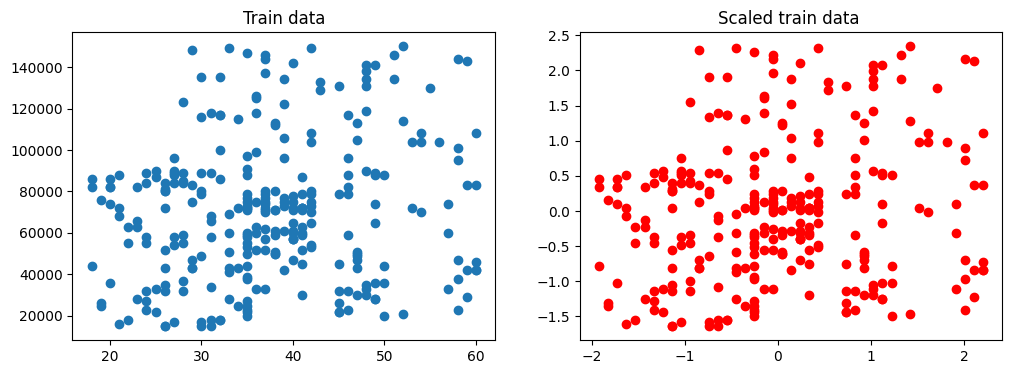

In [36]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,4))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Train data')

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], c='red')
ax2.set_title('Scaled train data ')
plt.show()

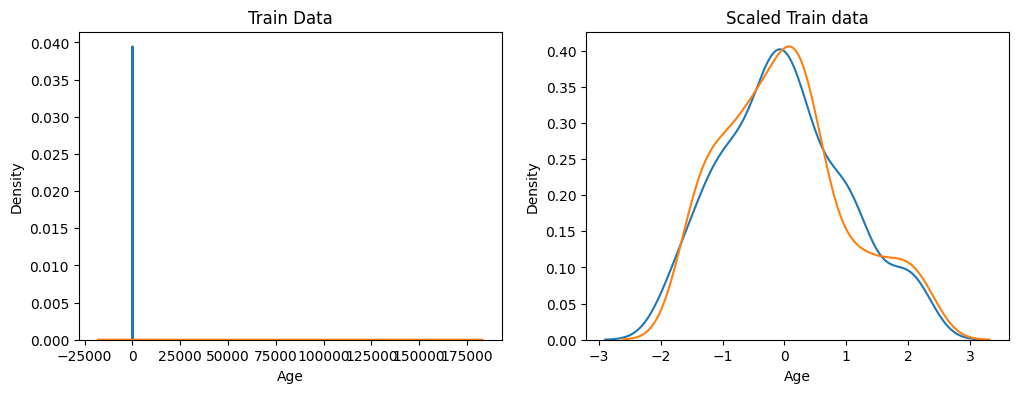

In [39]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.set_title('Train Data')
sns.kdeplot(X_train['Age'], ax=ax1 )
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1 )

ax2.set_title('Scaled Train data')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'] , ax= ax2)

plt.show()

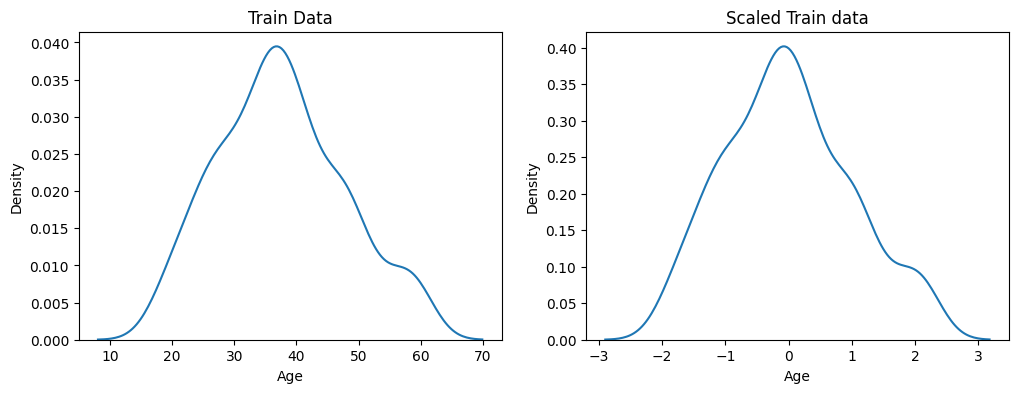

In [40]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.set_title('Train Data')
sns.kdeplot(X_train['Age'], ax=ax1 )


ax2.set_title('Scaled Train data')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)

plt.show()

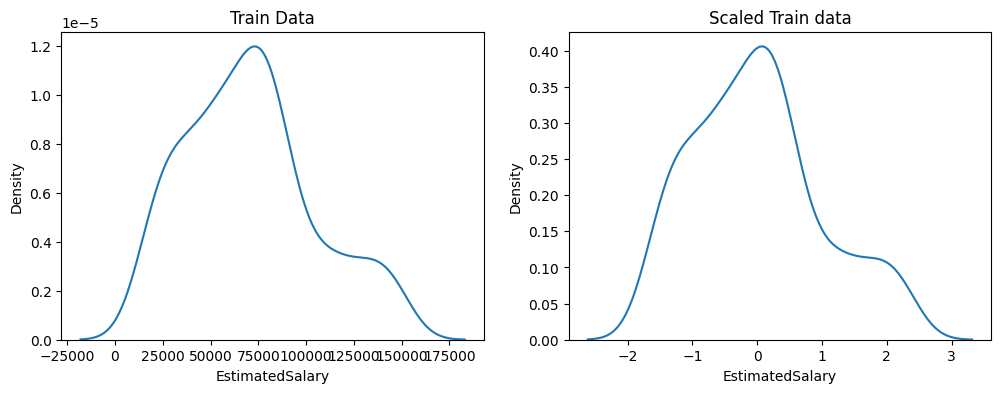

In [41]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.set_title('Train Data')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1 )

ax2.set_title('Scaled Train data')
sns.kdeplot(X_train_scaled['EstimatedSalary'] , ax= ax2)

plt.show()

# **Working with logistic regression**

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [55]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [70]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


In [71]:
y_pred = lr.predict(X_test)
y_pred_scaled  = lr_scaled.predict(X_test_scaled)

In [72]:
X_test.describe()

,Age,EstimatedSalary
count,120.000000,120.000000
mean,37.841667,67766.666667
std,11.165671,34502.644725
min,18.000000,16000.000000
25%,28.750000,40500.000000
50%,37.000000,63000.000000
75%,47.000000,86000.000000
max,60.000000,150000.000000


In [56]:
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0])

AttributeError: 'numpy.ndarray' object has no attribute 'describe'

In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [49]:
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred_scaled))


0.85
0.85


array([<Axes: ylabel='Predicted 0'>, <Axes: ylabel='Predicted 1'>],
      dtype=object)

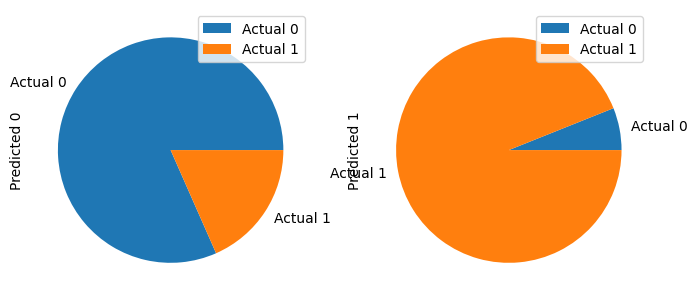

In [65]:
pd.DataFrame(confusion_matrix(y_test, y_pred_scaled), columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1']).plot.pie(subplots=True, figsize=(8,8))